In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import windspharm as ws
import pandas as pd

In [2]:
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def var_prepper(da, months_list, wghts_bool=True):
    da_sel=extract_seasonal_data(da, months_list)
    ##1 Anomalies
    da_an=compute_anomaly(da_sel)
    print('Anomalies computed')
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    print('Data is detrended')
    ##cut the weight by latitude part
    da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season= da_wght #extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    #da_masked=sea_mask(da_season_mean) #not necessary for 500hPa?
    da_masked=da_season_mean.to_dataset(name='Z500')
    return da_masked

In [3]:
ds = xr.open_dataset("ERA5_dyn_data_ready/uv500_all.nc", chunks={"time": 10})
ds_mod=ds.sel(pressure_level=500).drop_vars('pressure_level').rename({'valid_time': 'time'})
ds_SON=extract_seasonal_data(ds_mod, [9,10,11])
ds_DJF=extract_seasonal_data(ds_mod, [12,1,2])

In [4]:
ds_SON

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 6916, longitude: 360, latitude: 91)
Coordinates:
  * time       (time) datetime64[ns] 55kB 1950-09-01 1950-09-02 ... 2025-11-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 0.0 -1.0 -2.0 -3.0 ... -88.0 -89.0 -90.0
Data variables:
    u          (time, latitude, longitude) float32 906MB dask.array<chunksize=(1, 91, 360), meta=np.ndarray>
    v          (time, latitude, longitude) float32 906MB dask.array<chunksize=(1, 91, 360), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    Conventions:               CF-1.7
    institution:               European Centre for Medium-Range Weather Forec...
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    history:                   Sat Apr 11 10:42:20 2026: cdo -O -P 4 -z zip_4...
    cdo_openmp_thread_number:  4
    CDO:                       Climate Data Operators version 2.2.2 (https://...

In [5]:
psi_list = []

for t in range(ds_SON['u'].sizes["time"]):
    w = ws.standard.VectorWind(ds_SON['u'].isel(time=t), ds_SON['v'].isel(time=t))
    psi = w.streamfunction()  # Get output grid coordinates
    psi_da = xr.DataArray(
        psi,
        coords={'longitude': ds_SON.longitude, 'latitude': ds_SON.latitude},
        dims=('latitude', 'longitude')
    )
    psi_list.append(psi_da)
#print(psi_list)
psi_SON = xr.concat(psi_list, dim="time")
psi_SON["time"] = ds_SON["time"].isel(time=slice(0, len(psi_list)))
#psi_SON = xr.concat(psi_list, dim="time")
#psi_SON["time"] = ds_SON["time"]

display(psi_SON)

<xarray.DataArray (time: 6916, latitude: 91, longitude: 360)> Size: 906MB
array([[[-8.04894240e+07, -8.04894240e+07, -8.04894240e+07, ...,
         -8.04894240e+07, -8.04894240e+07, -8.04894240e+07],
        [-8.02330400e+07, -8.02132960e+07, -8.01938480e+07, ...,
         -8.02937520e+07, -8.02732800e+07, -8.02530400e+07],
        [-8.14511840e+07, -8.14313840e+07, -8.14119360e+07, ...,
         -8.15132800e+07, -8.14920720e+07, -8.14714080e+07],
        ...,
        [ 1.04391088e+08,  1.04432328e+08,  1.04475472e+08, ...,
          1.04278832e+08,  1.04314328e+08,  1.04351760e+08],
        [ 1.08722272e+08,  1.08740640e+08,  1.08759896e+08, ...,
          1.08672472e+08,  1.08688176e+08,  1.08704784e+08],
        [ 1.11790368e+08,  1.11790368e+08,  1.11790368e+08, ...,
          1.11790368e+08,  1.11790368e+08,  1.11790368e+08]],

       [[-8.00338560e+07, -8.00338560e+07, -8.00338560e+07, ...,
         -8.00338560e+07, -8.00338560e+07, -8.00338560e+07],
        [-7.99224640e+07, -7.99188640e+07, -7.99155040e+07, ...,
         -7.99347680e+07, -7.99304240e+07, -7.99263200e+07],
        [-8.12455360e+07, -8.12407040e+07, -8.12364000e+07, ...,
         -8.12629600e+07, -8.12566880e+07, -8.12508560e+07],
...
          5.40481360e+07,  5.40314720e+07,  5.40138240e+07],
        [ 5.30903280e+07,  5.30845720e+07,  5.30786040e+07, ...,
          5.31062720e+07,  5.31011800e+07,  5.30958560e+07],
        [ 5.26008800e+07,  5.26008800e+07,  5.26008800e+07, ...,
          5.26008800e+07,  5.26008800e+07,  5.26008800e+07]],

       [[-7.79354400e+07, -7.79354400e+07, -7.79354400e+07, ...,
         -7.79354400e+07, -7.79354400e+07, -7.79354400e+07],
        [-7.91020880e+07, -7.91333920e+07, -7.91642320e+07, ...,
         -7.90055760e+07, -7.90381760e+07, -7.90703520e+07],
        [-7.94380800e+07, -7.94820480e+07, -7.95252240e+07, ...,
         -7.93014400e+07, -7.93477840e+07, -7.93933360e+07],
        ...,
        [ 5.60714240e+07,  5.60599240e+07,  5.60484560e+07, ...,
          5.61058200e+07,  5.60943920e+07,  5.60829240e+07],
        [ 5.56710160e+07,  5.56675560e+07,  5.56640720e+07, ...,
          5.56811720e+07,  5.56778400e+07,  5.56744480e+07],
        [ 5.53993760e+07,  5.53993760e+07,  5.53993760e+07, ...,
          5.53993760e+07,  5.53993760e+07,  5.53993760e+07]]],
      shape=(6916, 91, 360), dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 0.0 -1.0 -2.0 -3.0 ... -88.0 -89.0 -90.0
  * time       (time) datetime64[ns] 55kB 1950-09-01 1950-09-02 ... 2025-11-30

In [6]:
psi_list = []

for t in range(ds_DJF['u'].sizes["time"]):
    w = ws.standard.VectorWind(ds_DJF['u'].isel(time=t), ds_DJF['v'].isel(time=t))
    psi = w.streamfunction()  # Get output grid coordinates
    psi_da = xr.DataArray(
        psi,
        coords={'longitude': ds_DJF.longitude, 'latitude': ds_DJF.latitude},
        dims=('latitude', 'longitude')
    )
    psi_list.append(psi_da)
#print(psi_list)
psi_DJF = xr.concat(psi_list, dim="time")
psi_DJF["time"] = ds_DJF["time"].isel(time=slice(0, len(psi_list)))
#psi_DJF = xr.concat(psi_list, dim="time")
#psi_DJF["time"] = ds_DJF["time"]

display(psi_DJF)

<xarray.DataArray (time: 6859, latitude: 91, longitude: 360)> Size: 899MB
array([[[-52954744., -52954744., -52954744., ..., -52954744.,
         -52954744., -52954744.],
        [-53704220., -53699192., -53694076., ..., -53718684.,
         -53713984., -53709160.],
        [-53920712., -53890940., -53860416., ..., -54003340.,
         -53977116., -53949504.],
        ...,
        [ 44613448.,  44646188.,  44678448., ...,  44512372.,
          44546532.,  44580224.],
        [ 43972572.,  43986496.,  44000292., ...,  43930068.,
          43944352.,  43958520.],
        [ 43756904.,  43756904.,  43756904., ...,  43756904.,
          43756904.,  43756904.]],

       [[-52243628., -52243628., -52243628., ..., -52243628.,
         -52243628., -52243628.],
        [-53186124., -53179120., -53172044., ..., -53206600.,
         -53199872., -53193040.],
        [-53536296., -53507244., -53478264., ..., -53622516.,
         -53594076., -53565288.],
...
        [ 68189472.,  68246664.,  68303472., ...,  68016304.,
          68074224.,  68131976.],
        [ 68580440.,  68602144.,  68623800., ...,  68515176.,
          68536944.,  68558704.],
        [ 68904744.,  68904744.,  68904744., ...,  68904744.,
          68904744.,  68904744.]],

       [[-64012088., -64012084., -64012084., ..., -64012088.,
         -64012088., -64012088.],
        [-65203868., -65209352., -65214204., ..., -65183756.,
         -65191056., -65197764.],
        [-65608952., -65620156., -65629932., ..., -65566792.,
         -65582248., -65596308.],
        ...,
        [ 70701592.,  70727184.,  70752728., ...,  70624920.,
          70650408.,  70675984.],
        [ 70321632.,  70332408.,  70343168., ...,  70289248.,
          70300048.,  70310848.],
        [ 70133616.,  70133616.,  70133616., ...,  70133616.,
          70133616.,  70133616.]]], shape=(6859, 91, 360), dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * latitude   (latitude) float64 728B 0.0 -1.0 -2.0 -3.0 ... -88.0 -89.0 -90.0
  * time       (time) datetime64[ns] 55kB 1950-01-01 1950-01-02 ... 2025-12-31

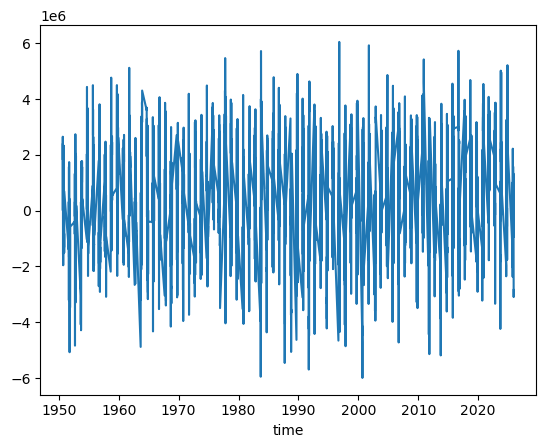

In [7]:
psi_SON.mean(dim=['latitude', 'longitude']).plot()

In [8]:
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def var_prepper(da, months_list):
    da_sel=extract_seasonal_data(da, months_list)
    ##1 Anomalies
    da_an=compute_anomaly(da_sel)
    print('Anomalies computed')
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    print('Data is detrended')
    ##cut the weight by latitude part
    da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season= da_wght #extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    #da_masked=sea_mask(da_season_mean) #not necessary for 500hPa?
    da_masked=da_season_mean.to_dataset(name='Z500')
    return da_masked

In [9]:
psi_SON_prepped=var_prepper(psi_SON, [9,10,11])
psi_DJF_prepped=var_prepper(psi_DJF, [12,1,2])

Anomalies computed
Data is detrended
Anomalies computed
Data is detrended


In [10]:
psi_finished_SON=psi_SON_prepped.rename({'Z500': 'psi'})
psi_finished_DJF=psi_DJF_prepped.rename({'Z500': 'psi'})

In [12]:
path='ERA5_dyn_data_ready/'
psi_finished_SON.to_netcdf(path+'psi500_SON.nc')
psi_finished_DJF.to_netcdf(path+'psi500_DJF.nc')

PermissionError: [Errno 13] Permission denied: '/home/glattus/work/ERA5_dyn_data_ready/psi500_SON.nc'

In [13]:
psi_climatology_SON=compute_anomaly(psi_SON)
psi_climatology_DJF=compute_anomaly(psi_DJF)

psi_climatology_DJF.to_netcdf(path+'psi500_climatology_DJF.nc')
psi_climatology_SON.to_netcdf(path+'psi500_climatology_SON.nc')